In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.datasets import fashion_mnist
import keras.models as models
import keras.layers as layers
from keras import regularizers
from keras.layers import Dropout

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense,Activation,Flatten,Dropout,Conv2D, MaxPooling2D, LeakyReLU
from tensorflow.keras.utils import to_categorical   #for the categorical data

In [3]:
print(keras.__version__)

3.13.2


In [4]:
#import the dataset #x: Images and Y: labels of the images
(train_X,train_Y),(test_X,test_Y)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


9


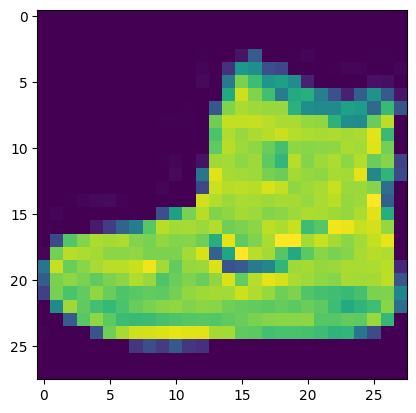

In [5]:
plt.imshow(train_X[0])
print(train_Y[0])

In [6]:
print(train_X.shape,train_Y.shape)

(60000, 28, 28) (60000,)


In [7]:
print(test_X.shape, test_Y.shape)

(10000, 28, 28) (10000,)


In [8]:
classes=np.unique(train_Y)
nClasses=len(classes)
print(classes)
print(nClasses)

[0 1 2 3 4 5 6 7 8 9]
10


In [9]:
train_X=train_X.reshape(-1,28,28,1)
test_X=test_X.reshape(-1,28,28,1)

In [10]:
print(train_X.shape,train_Y.shape)
print(test_X.shape, test_Y.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [11]:
#Range of pixel values for each type of image
#Black-White: 0-1
#Grayscale: 0-255
#RGB: (0-255)*3

In [12]:
#converting the values of the pixels from 0-1
#type-conversion
train_X=train_X.astype('float32')
test_X=test_X.astype('float32')
train_X=train_X/255
test_X=test_X/255

In [13]:
train_Y_one_hot=to_categorical(train_Y)
test_Y_one_hot=to_categorical(test_Y)

In [14]:
train_Y[0]

np.uint8(9)

In [15]:
train_Y_one_hot[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [16]:
#Model training task

In [17]:
from sklearn.model_selection import train_test_split
train_X,valid_X,train_label,valid_label=train_test_split(train_X,train_Y_one_hot,test_size=0.2,random_state=13)

In [18]:
train_X.shape,valid_X.shape,train_label.shape,valid_label.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

In [19]:
#Basic CNN model Develop
#Regularization and Dropout
#2nd CNN MODEL DEVELOPMENT

In [20]:
batch_size=64
epochs=20
num_classes=10

In [21]:
model=tf.keras.Sequential()

In [22]:
#1st hidden layer
model.add(tf.keras.layers.Conv2D(32,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [23]:
#2nd hidden layer
model.add(tf.keras.layers.Conv2D(64,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

In [24]:
#3rd hidden layer
model.add(tf.keras.layers.Conv2D(128,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

In [25]:
model.add(tf.keras.layers.Flatten())

In [26]:
model.add(tf.keras.layers.Dense(128,activation='linear'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))#output final layer

In [27]:
model.compile(loss=tf.keras.losses.categorical_crossentropy,optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])

In [28]:
48000/64

750.0

In [29]:
model_train=model.fit(train_X,train_label,batch_size=64,epochs=20,verbose=1,validation_data=(valid_X,valid_label))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.8284 - loss: 0.4694 - val_accuracy: 0.8547 - val_loss: 0.4008
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 106ms/step - accuracy: 0.8946 - loss: 0.2891 - val_accuracy: 0.8869 - val_loss: 0.3163
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.9110 - loss: 0.2400 - val_accuracy: 0.9031 - val_loss: 0.2604
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 115ms/step - accuracy: 0.9213 - loss: 0.2121 - val_accuracy: 0.9160 - val_loss: 0.2314
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 114ms/step - accuracy: 0.9320 - loss: 0.1846 - val_accuracy: 0.9146 - val_loss: 0.2372
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 105ms/step - accuracy: 0.9383 - loss: 0.1657 - val_accuracy: 0.9153 - val_loss: 0.2364
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 105ms/step - accuracy: 0.9466 - loss: 0.1416 - val_accuracy: 0.9169 - val_loss: 0.2342
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9541 - loss: 

In [30]:
testing_evaluation=model.evaluate(test_X,test_Y_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9172 - loss: 0.4736


In [31]:
testing_evaluation  #loss,accuracy

[0.47360697388648987, 0.9172000288963318]

In [32]:
model_train.history

{'accuracy': [0.8283958435058594,
  0.8945833444595337,
  0.911020815372467,
  0.9212916493415833,
  0.9320208430290222,
  0.9382708072662354,
  0.9465625286102295,
  0.9540625214576721,
  0.960770845413208,
  0.9670833349227905,
  0.9712916612625122,
  0.9741874933242798,
  0.9783750176429749,
  0.981374979019165,
  0.984291672706604,
  0.9854375123977661,
  0.9862708449363708,
  0.9886041879653931,
  0.9862916469573975,
  0.9895625114440918],
 'loss': [0.46935391426086426,
  0.2890775203704834,
  0.23998883366584778,
  0.21206150949001312,
  0.18457205593585968,
  0.1656607687473297,
  0.1416468322277069,
  0.12289515882730484,
  0.1030309647321701,
  0.0894603356719017,
  0.07718116044998169,
  0.06579803675413132,
  0.057516973465681076,
  0.04868756979703903,
  0.043110441416502,
  0.03966635838150978,
  0.0360206700861454,
  0.030371813103556633,
  0.036577481776475906,
  0.027996139600872993],
 'val_accuracy': [0.8546666502952576,
  0.8869166374206543,
  0.903083324432373,
  0.9

In [33]:
accuracy=model_train.history['accuracy']
val_accuracy=model_train.history['val_accuracy']
loss=model_train.history['loss']
val_loss=model_train.history['val_loss']
epochs=range(len(accuracy))

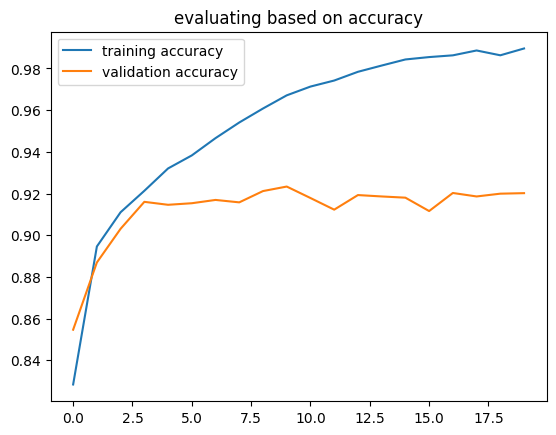

In [34]:
plt.plot(epochs,accuracy,label='training accuracy')
plt.plot(epochs,val_accuracy,label='validation accuracy')
plt.title('evaluating based on accuracy')
plt.legend()
plt.show()

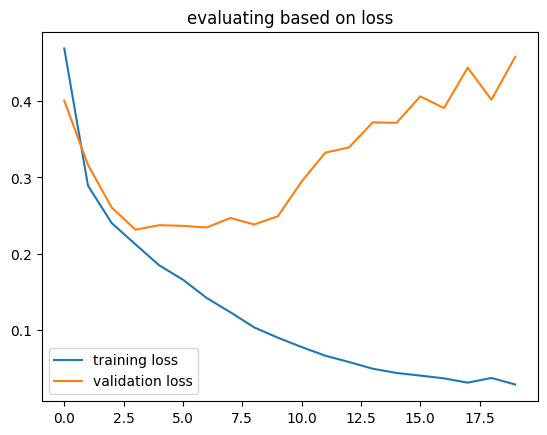

In [35]:
plt.plot(epochs,loss,label='training loss')
plt.plot(epochs,val_loss,label='validation loss')
plt.title('evaluating based on loss')
plt.legend()
plt.show()

Regularization

In [36]:
regmodel=tf.keras.Sequential()
#1st hidden layer
regmodel.add(tf.keras.layers.Conv2D(32,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.25))
#2nd hidden layer
regmodel.add(tf.keras.layers.Conv2D(64,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.25))
#3rd hidden layer
regmodel.add(tf.keras.layers.Conv2D(128,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.40))

regmodel.add(tf.keras.layers.Flatten())
regmodel.add(tf.keras.layers.Dense(128,activation='linear'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.Dropout(0.3))
regmodel.add(tf.keras.layers.Dense(num_classes,activation='softmax'))#output final layer

In [37]:
regmodel.compile(loss=tf.keras.losses.categorical_crossentropy,optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])

In [38]:
reg_model_train=regmodel.fit(train_X,train_label,batch_size=64,epochs=20,verbose=1,validation_data=(valid_X,valid_label))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 111ms/step - accuracy: 0.7806 - loss: 0.5919 - val_accuracy: 0.8628 - val_loss: 0.3653
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 148s 120ms/step - accuracy: 0.8615 - loss: 0.3774 - val_accuracy: 0.8858 - val_loss: 0.3126
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.8782 - loss: 0.3296 - val_accuracy: 0.8978 - val_loss: 0.2809
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 117ms/step - accuracy: 0.8884 - loss: 0.2998 - val_accuracy: 0.9030 - val_loss: 0.2651
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 112ms/step - accuracy: 0.8947 - loss: 0.2860 - val_accuracy: 0.9064 - val_loss: 0.2540
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 121ms/step - accuracy: 0.8987 - loss: 0.2692 - val_accuracy: 0.9058 - val_loss: 0.2510
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 116ms/step - accuracy: 0.9045 - loss: 0.2561 - val_accuracy: 0.9097 - val_loss: 0.2394
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.9056 - los